In [42]:
%load_ext autoreload
%autoreload 2
%time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CPU times: user 4 µs, sys: 1e+03 ns, total: 5 µs
Wall time: 8.34 µs


In [43]:
import sys
import numpy as np
sys.path.append("../../")
import data_loading as dl

from microfit import run_plotter as rp

from microfit import histogram as hist

In [44]:
RUN = ["1"]
rundata = dl.load_sample(
    "1",                 
    "numupresel",        
    "mc",           
    use_bdt=True,
    loadnumuvariables=True,
    loadshowervariables=True,
    loadsystematics=True,
    load_numu_tki=True,
    load_nue_tki=True,    
    enable_cache=True,
)

In [20]:
#print(rundata.columns.values)

#### Apply the event selection for the numu sideband ####

#### Try Testing out Gardiner's stuff ####

In [45]:
rundata_sel_nue = rundata.query("Signal_1e1p == True")
rundata_sel_numu = rundata.query("Signal_1mu1p == True")

array([[<AxesSubplot:title={'center':'TrueDeltaPT_1mu1p'}>]], dtype=object)

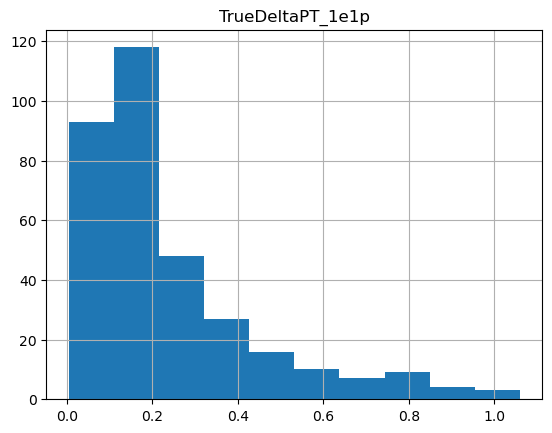

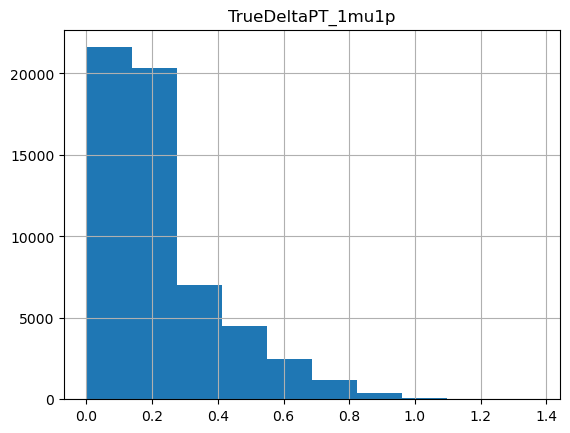

In [46]:
rundata_sel_nue.hist(column="TrueDeltaPT_1e1p")
rundata_sel_numu.hist(column="TrueDeltaPT_1mu1p")


## Comparing selection efficiency and purity 

In [55]:
from microfit import selections as sel
import pandas as pd

# Choose your selection and preselection category
## 1mu1p
selection_1mu1p   = "SG_1MU1P"
preselection_1mu1p = "SG_1MUNP"

## 1e1p
selection_1e1p   = "TKI_1e1p" #"OneP_NPBDTXS"
preselection_1e1p = "OneP"

# Build the full query (e.g. sel_CCNp0pi and sel_CC1p0pi)
query_1mu1p = f"{sel.preselection_categories[preselection_1mu1p]['query']} and {sel.selection_categories[selection_1mu1p]['query']}"
sel_title_1mu1p = sel.selection_categories[selection_1mu1p]['title']

query_1e1p = f"{sel.preselection_categories[preselection_1e1p]['query']} and {sel.selection_categories[selection_1e1p]['query']}"
sel_title_1e1p = sel.selection_categories[selection_1e1p]['title']

#print(type(query_1e1p))
#all_mc = pd.concat([df for k, df in rundata.items() if k in ['data', 'ext']])
all_mc = rundata # Only one sample in load_sample


sel_mc_1mu1p = all_mc.query(query_1mu1p, engine='python')
sel_mc_1e1p  = all_mc.query(query_1e1p, engine='python')

# # # Define the signal category
# # all_sig_1mu1p  = all_mc['category_1mu1p'] = 16
# # all_sig_1e1p   = all_mc['category_1e1p']  = 12
all_sig_1mu1p = all_mc['Signal_1mu1p'] == True
all_sig_1e1p  = all_mc['Signal_1e1p']  == True

# Total signal and background before cuts
tot_sig_1mu1p = np.sum(all_mc.loc[all_sig_1mu1p, 'weights'])
tot_bkg_1mu1p = np.sum(all_mc.loc[~all_sig_1mu1p, 'weights'])

tot_sig_1e1p = np.sum(all_mc.loc[all_sig_1e1p, 'weights'])
tot_bkg_1e1p = np.sum(all_mc.loc[~all_sig_1e1p, 'weights'])


print("1mu1p: ")
print(f"Total candidate signal events (before selection): {tot_sig_1mu1p}")
print(f"Total candidate background events (before selection): {tot_bkg_1mu1p}")

print("1e1p: ")
print(f"Total candidate signal events (before selection): {tot_sig_1e1p}")
print(f"Total candidate background events (before selection): {tot_bkg_1e1p}")

KeyError: 'weights'

In [51]:

# Apply selection
is_1mu1p = sel_mc_1mu1p['Signal_1mu1p'] == True  
is_1e1p  = sel_mc_1e1p['Signal_1e1p'] == True  

# 1mu1p
sel_sig_1mu1p = np.sum(sel_mc_1mu1p.loc[is_1mu1p, 'weights'])
sel_bkg_1mu1p = np.sum(sel_mc_1mu1p.loc[~is_1mu1p, 'weights'])
sel_evt_1mu1p = np.sum(sel_mc_1mu1p['weights'])

# 1mu1p
sel_sig_1e1p = np.sum(sel_mc_1e1p.loc[is_1e1p, 'weights'])
sel_bkg_1e1p = np.sum(sel_mc_1e1p.loc[~is_1e1p, 'weights'])
sel_evt_1e1p = np.sum(sel_mc_1e1p['weights'])



print('\nAfter cuts 1MU1P:')
print(f"Total signal events (selected): {sel_sig_1mu1p}")
print(f"Total background events (selected): {sel_bkg_1mu1p}")
print(f"Total selected events (sig + bkg): {sel_evt_1mu1p}")
print(f"sel_sig + sel_bkg = {sel_sig_1mu1p + sel_bkg_1mu1p}\n")

print('\nAfter cuts 1e1p:')
print(f"Total signal events (selected): {sel_sig_1e1p}")
print(f"Total background events (selected): {sel_bkg_1e1p}")
print(f"Total selected events (sig + bkg): {sel_evt_1e1p}")
print(f"sel_sig + sel_bkg = {sel_sig_1e1p + sel_bkg_1e1p}\n")


# Compute efficiency and purity
efficiency_1mu1p = (sel_sig_1mu1p / tot_sig_1mu1p) * 100 if tot_sig_1mu1p > 0 else 0
purity_1mu1p    = (sel_sig_1mu1p / sel_evt_1mu1p) * 100 if sel_evt_1mu1p > 0 else 0

efficiency_1e1p = (sel_sig_1e1p / tot_sig_1e1p) * 100 if tot_sig_1e1p > 0 else 0
purity_1e1p    = (sel_sig_1e1p / sel_evt_1e1p) * 100 if sel_evt_1e1p > 0 else 0

print(f"Selection: {sel_title_1mu1p}, {sel_title_1e1p}")
print(f"Efficiency: {efficiency_1mu1p:.2f}%, {efficiency_1e1p:.2f}%")
print(f"Purity: {purity_1mu1p:.2f}%, {purity_1e1p:.2f}%")


KeyError: 'weights'

In [ ]:
# print(type(all_mc))
# print(all_mc.head())
# #rundata.keys()
# for k, v in rundata.items():
#     print(k, type(v), getattr(v, "shape", None))


In [ ]:
# Apply selection
is_1e1p  = sel_mc['Signal_1e1p']  == True  
is_1mu1p = sel_mc['Signal_1mu1p'] == True  

# 1e1p
sel_sig_1e1p = np.sum(sel_mc.loc[is_1e1p, 'weights'])
sel_bkg_1e1p = np.sum(sel_mc.loc[~is_1e1p, 'weights'])
sel_evt_1e1p = np.sum(sel_mc['weights'])

# 1mu1p
sel_sig_1mu1p = np.sum(sel_mc.loc[is_1mu1p, 'weights'])
sel_bkg_1mu1p = np.sum(sel_mc.loc[~is_1mu1p, 'weights'])
sel_evt_1mu1p = np.sum(sel_mc['weights'])

print('\nAfter cuts:')
print(f"1e1p: Total signal events (selected): {sel_sig_1e1p}")
print(f"1e1p: Total background events (selected): {sel_bkg}")
print(f"1e1p: Total selected events (sig + bkg): {sel_evt}")
print(f"1e1p: sel_sig + sel_bkg = {sel_sig + sel_bkg}\n")

# Compute efficiency and purity
efficiency_1e1p = (sel_sig_1e1p / tot_sig_1e1p) * 100 if tot_sig_1e1p > 0 else 0
purity_1e1p.    = (sel_sig_1e1p / sel_evt_1e1p) * 100 if sel_evt_1e1p > 0 else 0

print(f"Selection: {sel_title}")
print(f"Efficiency: {efficiency_1e1p:.2f}%")
print(f"Purity: {purity_1e1p:.2f}%")


# DEBUG